In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sales = pd.read_csv("../data/processed/sales_features.csv")

sales["Date"] = pd.to_datetime(sales["Date"])

sales.head()

,Date,SKU,Units_Sold,Revenue,Price,Promotion,Year,Month,Day,DayOfWeek,Quarter
0,2024-01-01,SKU001,5,18320.25,3664.05,0,2024,1,1,0,1
1,2024-01-01,SKU002,15,57085.35,3805.69,0,2024,1,1,0,1
2,2024-01-01,SKU003,5,40391.15,8078.23,0,2024,1,1,0,1
3,2024-01-01,SKU004,5,34307.85,6861.57,0,2024,1,1,0,1
4,2024-01-01,SKU005,12,113918.64,9493.22,0,2024,1,1,0,1


In [3]:
daily_demand = (
    sales.groupby("Date")["Units_Sold"]
    .sum()
    .reset_index()
)

daily_demand.head()

,Date,Units_Sold
0,2024-01-01,667
1,2024-01-02,643
2,2024-01-03,641
3,2024-01-04,658
4,2024-01-05,619


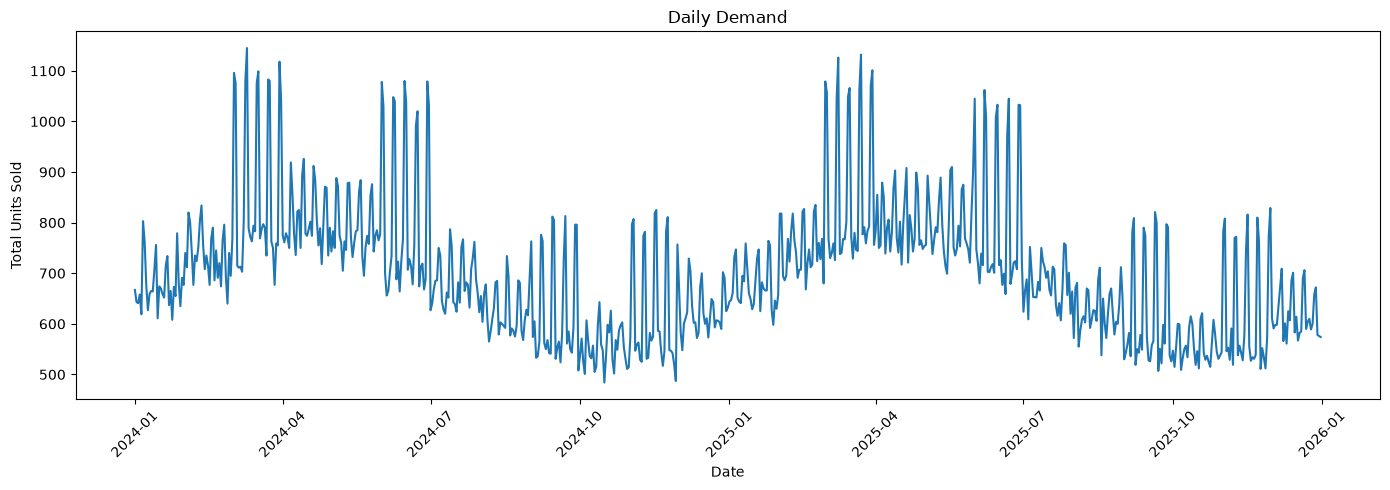

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_demand["Date"],
    daily_demand["Units_Sold"]
)

plt.title("Daily Demand")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
daily_demand["Lag_1"] = daily_demand["Units_Sold"].shift(1)
daily_demand["Lag_7"] = daily_demand["Units_Sold"].shift(7)
daily_demand["Lag_30"] = daily_demand["Units_Sold"].shift(30)

daily_demand.head(35)

,Date,Units_Sold,Lag_1,Lag_7,Lag_30
0,2024-01-01,667,NaN,NaN,NaN
1,2024-01-02,643,667.0,NaN,NaN
2,2024-01-03,641,643.0,NaN,NaN
3,2024-01-04,658,641.0,NaN,NaN
4,2024-01-05,619,658.0,NaN,NaN
5,2024-01-06,803,619.0,NaN,NaN
6,2024-01-07,762,803.0,NaN,NaN
7,2024-01-08,676,762.0,667.0,NaN
8,2024-01-09,627,676.0,643.0,NaN
9,2024-01-10,659,627.0,641.0,NaN


In [6]:
daily_demand["Rolling_7"] = (
    daily_demand["Units_Sold"]
    .rolling(7)
    .mean()
)

daily_demand["Rolling_30"] = (
    daily_demand["Units_Sold"]
    .rolling(30)
    .mean()
)

daily_demand.head(35)

,Date,Units_Sold,Lag_1,Lag_7,Lag_30,Rolling_7,Rolling_30
0,2024-01-01,667,NaN,NaN,NaN,NaN,NaN
1,2024-01-02,643,667.0,NaN,NaN,NaN,NaN
2,2024-01-03,641,643.0,NaN,NaN,NaN,NaN
3,2024-01-04,658,641.0,NaN,NaN,NaN,NaN
4,2024-01-05,619,658.0,NaN,NaN,NaN,NaN
5,2024-01-06,803,619.0,NaN,NaN,NaN,NaN
6,2024-01-07,762,803.0,NaN,NaN,684.714286,NaN
7,2024-01-08,676,762.0,667.0,NaN,686.000000,NaN
8,2024-01-09,627,676.0,643.0,NaN,683.714286,NaN
9,2024-01-10,659,627.0,641.0,NaN,686.285714,NaN


In [7]:
daily_demand = daily_demand.dropna().reset_index(drop=True)

In [8]:
daily_demand.shape

(701, 7)

In [9]:
daily_demand.head()

,Date,Units_Sold,Lag_1,Lag_7,Lag_30,Rolling_7,Rolling_30
0,2024-01-31,677,691.0,608.0,667.0,684.142857,676.466667
1,2024-02-01,740,677.0,673.0,643.0,693.714286,679.700000
2,2024-02-02,712,740.0,655.0,641.0,701.857143,682.066667
3,2024-02-03,820,712.0,779.0,658.0,707.714286,687.466667
4,2024-02-04,800,820.0,679.0,619.0,725.000000,693.500000


In [10]:
features = [
    "Lag_1",
    "Lag_7",
    "Lag_30",
    "Rolling_7",
    "Rolling_30"
]

X = daily_demand[features]
y = daily_demand["Units_Sold"]

In [11]:
split_index = int(len(daily_demand) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [12]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("Training period:")
print(daily_demand["Date"].iloc[:split_index].min())
print("to")
print(daily_demand["Date"].iloc[:split_index].max())

print("\nTesting period:")
print(daily_demand["Date"].iloc[split_index:].min())
print("to")
print(daily_demand["Date"].iloc[-1])

Training samples: 560
Testing samples: 141
Training period:
2024-01-31 00:00:00
to
2025-08-12 00:00:00

Testing period:
2025-08-13 00:00:00
to
2025-12-31 00:00:00


In [14]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 1.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 969.8 kB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [15]:
from sklearn.ensemble import RandomForestRegressor

In [16]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

In [17]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [18]:
comparison = pd.DataFrame({
    "Date": daily_demand["Date"].iloc[split_index:],
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

NameError: name 'y_pred' is not defined

In [19]:
y_pred = model.predict(X_test)

In [20]:
comparison = pd.DataFrame({
    "Date": daily_demand["Date"].iloc[split_index:],
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Date,Actual,Predicted
560,2025-08-13,627,599.346904
561,2025-08-14,626,608.263330
562,2025-08-15,606,607.687483
563,2025-08-16,688,658.256385
564,2025-08-17,711,651.350072
565,2025-08-18,538,599.065607
566,2025-08-19,650,578.987235
567,2025-08-20,602,614.399208
568,2025-08-21,572,600.316430
569,2025-08-22,619,592.422847


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 29.356640269003915
RMSE: 44.7931386727807
R² Score: 0.7246947802826988


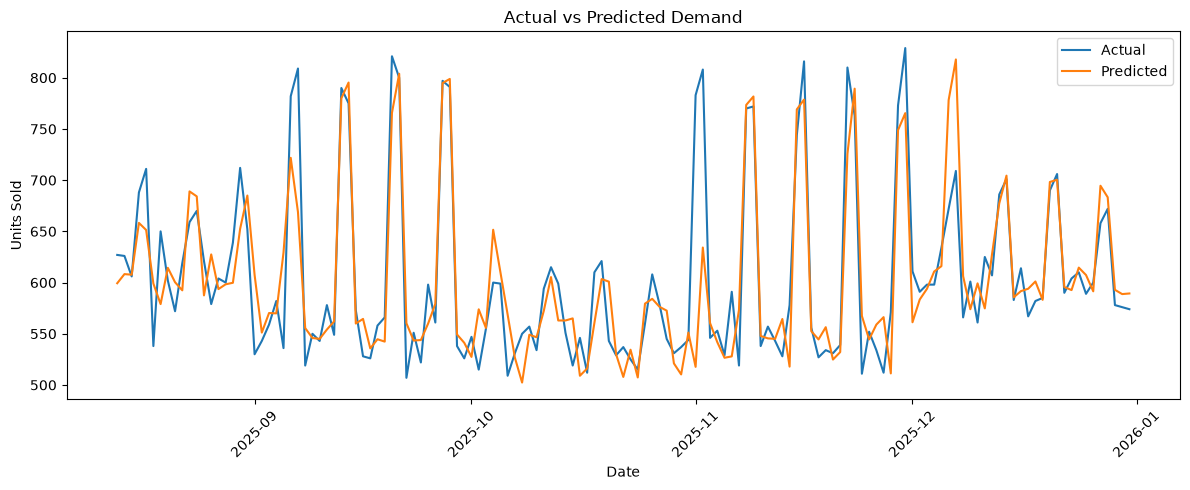

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="Predicted"
)

plt.title("Actual vs Predicted Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Lag_7,0.798790
3,Rolling_7,0.092511
0,Lag_1,0.057160
4,Rolling_30,0.027419
2,Lag_30,0.024120


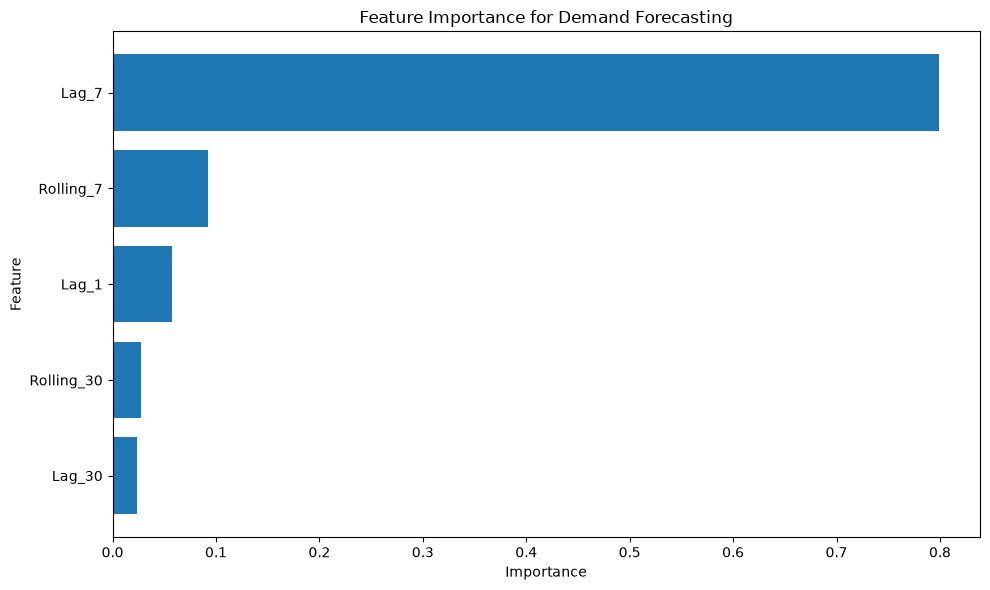

In [24]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Demand Forecasting")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

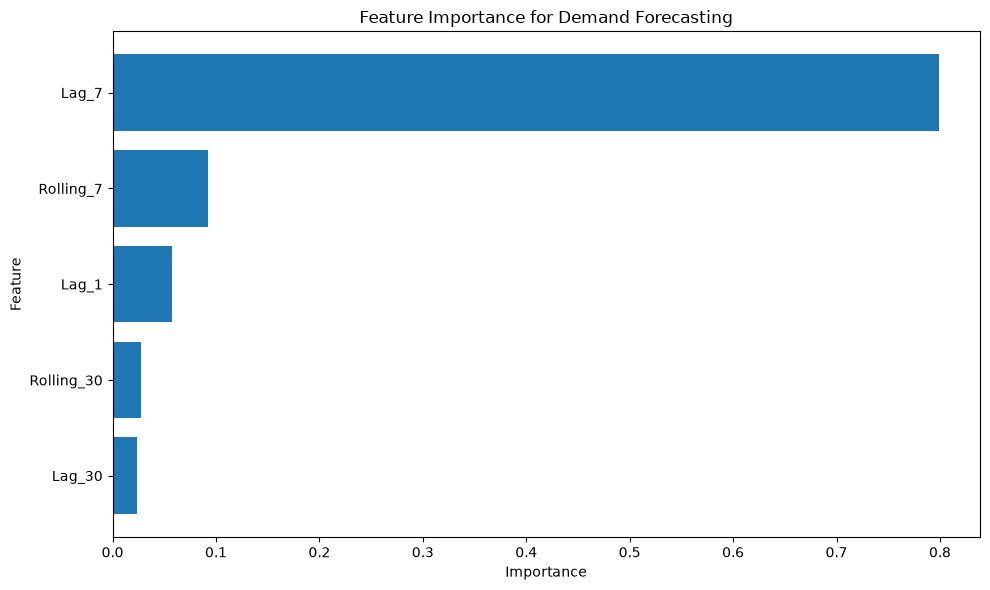

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Demand Forecasting")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [26]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    model,
    "../models/demand_forecast_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [27]:
os.makedirs("../data/processed", exist_ok=True)

comparison.to_csv(
    "../data/processed/demand_predictions.csv",
    index=False
)

print("Predictions saved successfully.")

Predictions saved successfully.


In [28]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.
